In [1]:
import introns
import pandas as pd
import numpy as np
import importlib
importlib.reload(introns)
import matplotlib.pyplot as plt
from termcolor import colored
import warnings
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
genome, genes = introns.create('allignmenty_all_2.fasta',
                               'allignmenty_all_2.gff',
                               genes_data_type='manual')

EL|STRG.5724.1|scaffold_3542:6373-8348 132 562
CCATG ATCCG CCCCC GAAGG
EL|STRG.5724.1|scaffold_3542:6373-8348 637 884
GGACC GCCCG ACACC AGAGG
left 1 EL|STRG.5724.1|scaffold_3542:6373-8348 636 883
CGGAC CGCCC GACAC CAGAG
left 2 EL|STRG.5724.1|scaffold_3542:6373-8348 635 882
CCGGA CCGCC CGACA CCAGA
left 3 EL|STRG.5724.1|scaffold_3542:6373-8348 634 881
ACCGG ACCGC CCGAC ACCAG
EL|STRG.5724.1|scaffold_3542:6373-8348 983 1286
AAACG GTCCT TTCAG GGCGG
left 1 EL|STRG.5724.1|scaffold_3542:6373-8348 982 1285
GAAAC GGTCC CTTCA GGGCG
right 1 EL|STRG.5724.1|scaffold_3542:6373-8348 984 1287
AACGG TCCTG TCAGG GCGGT
EL|STRG.5724.1|scaffold_3542:6373-8348 1444 1916
CCTGG GTTTT TCCAG GTCGG
left 1 EL|STRG.5724.1|scaffold_3542:6373-8348 1443 1915
ACCTG GGTTT TTCCA GGTCG
right 1 EL|STRG.5724.1|scaffold_3542:6373-8348 1445 1917
CTGGG TTTTC CCAGG TCGGG
right 2 EL|STRG.5724.1|scaffold_3542:6373-8348 1446 1918
TGGGT TTTCC CAGGT CGGGA
EH|STRG.10125.1|scaffold_4676:26801-34772 584 1350
TCATG CCCCA CCACG AGCTG
lef

In [3]:
k_labels = ['Intron K', 'Inron K', 'Intron K (EL, EG)', 'Intron K ', 'Exon K', "Intron K (5' partial)"]
nk_labels = ['Intron N', 'Intron N (EH)', 'Intron NK', 'Intron NK ', 'Intron N ', 'Intron NK (polimorfizm)']  
i_labels = ['Intron I', 'Intron I ', 'I', 'Intron P']
label_dict = {}
for i in k_labels:
    label_dict[i] = 'intron_K'
for i in nk_labels:
    label_dict[i] = 'intron_NK'
for i in i_labels:
    label_dict[i] = 'intron_I'
    
from Bio import SeqIO
count = {}

with open('/home/halakuc/genomy/21_11_03_manual_alignment_for_euglena_network/allignmenty_all_2.gb') as gb_file:
    for record in SeqIO.parse(gb_file, "genbank"):
        #print(record)
        gene_name = record.name
        source = 'manual_annotation'
        feature, start, end, score, strand, frame, attribute = '', '', '', '1000', '+', '.', '.'
        gene_start, gene_end = 1000000, 0
        exons = []
        for feature_listed in record.features:
            feature = feature_listed.type
            start, end = int(feature_listed.location.start.position), int(feature_listed.location.end.position)
            try:
                label = feature_listed.qualifiers['label'][0]
            except KeyError as exc:
                print(feature_listed)
                continue
            if label in label_dict.keys():
                label = label_dict[label]
                gene_obj = genes[gene_name]
            try:
                intron_obj = gene_obj.introns_dict[(start, end)]
                intron_obj.add_manual_annotation(label, start, end)
                if label not in count:
                    count[label] = 1
                else:
                    count[label] += 1
            except KeyError:
                pass

print(count)

{'intron_NK': 430, 'intron_K': 368, 'intron_I': 12}


In [4]:
introns_NK, introns_K, introns_I = [], [], []
genes_K, genes_NK, genes_both = [], [], []
exons = []

for gene_name, gene_obj in genes.items():
    for intron in gene_obj.introns:
        intron.add_test_annotation()
        if intron.man_annotation == 'intron_NK':
            introns_NK.append(intron)
        if intron.man_annotation == 'intron_K':
            introns_K.append(intron)
        if intron.man_annotation == 'intron_I':
            introns_I.append(intron)
    for exon in gene_obj.exons:
        exons.append(exon)
print('Intron_NK', len(introns_NK))
print('Intron_K', len(introns_K))
print('intron_I', len(introns_I))
print(len(introns_I + introns_K + introns_NK))
print('exon', len(exons))

Intron_NK 430
Intron_K 368
intron_I 12
810
exon 913


In [5]:
baseY = {'C', 'T'}
baseR = {'A', 'G'}

columns=['intron_obj', 'eY| i', 'e |Ri', 'C-G', 'A-T', 'G-C', 'CAG - CGT', 'iY| e', 'i |Re', 'klasa']
introns_set = pd.DataFrame(columns = columns)

def compute_characteristics(intron):
    e_y_cnt, i_r_cnt, i_C_cnt, i_A_cnt, i_G_cnt, i_CAG_cnt, i_y_cnt, e_r_cnt = 0, 0, 0, 0, 0, 0, 0, 0

    c, a, t, g = False, False, False, False
    if intron.prev_exon.sequence[-1] in baseY:
        e_y_cnt = 1
    if intron.sequence[0] in baseR:
        i_r_cnt = 1
    if intron.sequence[3] == 'C' and intron.sequence[-6] == 'G':
        c = True
        i_C_cnt = 1
    if intron.sequence[4] == 'A' and intron.sequence[-7] == 'T':
        a = True
        i_A_cnt = 1
    if intron.sequence[5] == 'G' and intron.sequence[-8] == 'C':
        g = True
        i_G_cnt = 1
    if c and a and g:
        i_CAG_cnt = 1
    if intron.sequence[-1] in baseY:
        i_y_cnt = 1
    if intron.next_exon.sequence[0] in baseR:
        e_r_cnt = 1
        
    return e_y_cnt, i_r_cnt, i_C_cnt, i_A_cnt, i_G_cnt, i_CAG_cnt, i_y_cnt, e_r_cnt

introns_variants, true_classes = [], []
#introny niekonwencjonalne = 1
for intron in introns_NK:  
    intron_df = pd.DataFrame([[intron, *compute_characteristics(intron), 1]], columns=columns)
    introns_set = introns_set.append(intron_df, ignore_index=True)
    introns_variants.append([compute_characteristics(i) for i in intron.variations+[intron]])
    true_classes.append(1)

#inne niż niekonwencjonalne = 0
for intron in introns_K+introns_I:
    intron_df = pd.DataFrame([[intron, *compute_characteristics(intron), 0]], columns=columns)
    introns_set = introns_set.append(intron_df, ignore_index=True)
    introns_variants.append([compute_characteristics(i) for i in intron.variations])
    true_classes.append(0)
print(len(introns_variants), len(true_classes))
introns_obj = introns_set['intron_obj']
introns_set.drop('intron_obj', axis=1, inplace = True)
columns = introns_set.columns
introns_set = introns_set.astype('int')
print(introns_set)

810 810
     eY| i  e |Ri  C-G  A-T  G-C  CAG - CGT  iY| e  i |Re  klasa
0        0      1    1    0    0          0      1      1      1
1        1      1    1    0    1          0      1      1      1
2        0      0    1    0    0          0      0      1      1
3        1      0    1    1    0          0      1      0      1
4        1      1    1    1    0          0      1      1      1
..     ...    ...  ...  ...  ...        ...    ...    ...    ...
805      0      1    0    0    0          0      0      1      0
806      0      1    1    1    1          1      0      1      0
807      1      1    1    1    0          0      1      1      0
808      0      1    0    0    1          0      0      0      0
809      0      1    1    1    0          0      0      1      0

[810 rows x 9 columns]


In [6]:
'''podział intronów na 4 zbiory, zapisywanie źle zaklasyfikowanych'''
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
import itertools



def add_misclassified_column(name,clf, introns_set=introns_set):
    n = int(len(introns_set)/4)
    i_s = introns_set.sample(frac=1)
    columns = list(i_s.columns)+['predprob', 'predclass']
    
    slices1 = list(range(0, len(i_s), n))[:-1]
    slices2 = slices1[1:]+[len(i_s)-1]
    print(slices1,slices2)
    newdfs=[]
    for start,end in zip(slices1, slices2):
        test = i_s[start:end]
        train = i_s.drop(list(range(start,end)))
        print(len(train), len(test))
        X_train, Y_train = train[train.columns[:-1]], train[train.columns[-1]]
        X_test, Y_test = test[test.columns[:-1]], test[test.columns[-1]]
        
        clf.fit(X_train, Y_train)
        predprob = clf.predict_proba(X_test)
        predclass = clf.predict(X_test)
        print(predprob[:,1].shape, predclass.shape, test.shape)
        #test['predprob']=predprob[:,1]
        #test['predclass']=predclass
        newdfs.append(test.assign(predprob=predprob[:,1], predclass=predclass))
    return pd.concat(newdfs, ignore_index=False)
'''
    print(name)
    predictions = np.empty((1,3))
    for ind, set1 in enumerate(sets):
        X_train, Y_train = rest_sets[rest_sets.columns[:-1]], rest_sets[rest_sets.columns[-1]]
        X_test, Y_test = set1[set1.columns[:-1]], set1[set1.columns[-1]]
        clf.fit(X_train, Y_train)
        predprob = clf.predict_proba(X_test)
        predclass = clf.predict(X_test)
        predictions = np.append(predictions, np.hstack((predprob, predclass)), axis=0)
    return predictions[1:]
'''

predictions = add_misclassified_column("gp", GaussianProcessClassifier(1.0 * RBF(1.0)), introns_set)
predictions

[0, 202, 404, 606] [202, 404, 606, 809]
608 202
(202,) (202,) (202, 9)
608 202
(202,) (202,) (202, 9)
608 202
(202,) (202,) (202, 9)
607 203


KeyboardInterrupt: 

In [ ]:
wrong_predictions = predictions[predictions['klasa'] != predictions['predclass']]
'''
f = open("wrongly_predicted_introns_4sets.fasta", 'w')
for ind, wi in zip(wrong_predictions.index, introns_obj.iloc[wrong_predictions.index]):
    #print(">%s\n%s\n" %(wi.__str__(), wi.sequence))
    s = wi.prev_exon.sequence[-10:] + wi.sequence + wi.next_exon.sequence[:10]
    knk = "NK" if wrong_predictions.loc[ind]['predclass'] == 1 else "K/I"
    f.write(">%s || manual: %s predicted: %s\n%s\n" %(wi.__str__(), wi.man_annotation, knk, s))
f.close()'''

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(10,3))

#ax[0].hist(probs_0["0"], label='0', bins=20, alpha=0.6, color='green');
ax[0].hist(probs_0['1'], label='1', bins=20);
ax[0].set_title("probs for k/i")
ax[0].legend()

#ax[1].hist(probs_1["0"], label='0', bins=20, alpha=0.6, color='green');
ax[1].hist(probs_1['1'], label='1', bins=20);
ax[1].set_title("probs for nk")
ax[1].legend()
i_0, i_1 = introns_set[introns_set['klasa']==0], introns_set[introns_set['klasa']==1]
fig, ax = plt.subplots(2,1, figsize=(10,10))
ax[0].set_title("Probabilities of being nk")
ax[0].hist(i_0['prob1'], label='k/i', bins=20, alpha=0.75, color="green");
ax[0].hist(i_1['prob1'], label='n', bins=20, alpha=0.75, color="red");

ax[0].legend()

ax[1].set_title("Probabilities of being nk")
ax[1].hist(i_0['prob1'], label='k/i', bins=20, alpha=0.75, color="green");
ax[1].hist(i_1['prob1'], label='n', bins=20, alpha=0.75, color="red");
ax[1].set_ylim((0,50))
ax[1].legend()

In [ ]:
sus_k = probs_0.index[probs_0['1']>.5]
sus_nk = probs_1.index[probs_1['1']<.5]

pro

In [7]:
df_correct = pd.DataFrame(columns=["class", "position"])
probs = [[], []]
#correct_class=[]
#correct_position=[]
for intron, true_class in zip(introns_variants, true_classes):
    if not intron: continue
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        p = clf.predict_proba(intron)
    s = sorted(p, key = lambda x: x[0])
    max_0, max_1 = s[-1], s[0]
    if len(s)==1:
        correct_class.append(True)
        correct_position.append(True)
    
    elif (max_0[0]>max_1[1] and true_class==0):
        correct_class.append(True)
        if np.all([max_0, p[0]]): correct_position.append(True)
        else: correct_position.append(False)
        
    elif (max_0[0]<max_1[1] and true_class==1):
        correct_class.append(True)
        if np.all([max_1, p[0]]): correct_position.append(True)
        else: correct_position.append(False)
    else:
        correct_class.append(False)
        correct_position.append(False)
    df_correct.append(pd.Series(correct_class, correct_position), ignore_index=True)
print(sum(correct_class), sum(correct_position))

NameError: name 'clf' is not defined

In [ ]:
df_correct = pd.DataFrame(columns=["class", "position"])
probs = [[], []]
for intron, true_class in list(zip(introns_variants, true_classes))[:5]:
    correct_class=None
    correct_position=None
    
    if not intron: continue
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        p = clf.predict_proba(intron)
    probs = [j for _,j in p]
    s = sorted(probs)
    max_0, max_1 = s[0], s[-1]
    print(max_0, max_1)
    
    if len(s)==1:
        correct_position=True
        if probs.index(max_0)==0 and true_class==0: correct_position=True
        elif probs.index(max_1)==1 and true_class==0: correct_position=True
        else: correct_position=False
    
    
    df_correct.append(pd.Series([correct_class, correct_position]), ignore_index=True)

In [ ]:
print(sum(correct_class), sum(correct_class)/len(correct_class))
print(sum(correct_position), sum(correct_position)/len(correct_position))

df = pd.DataFrame(columns=["class", "position"])
df['class'] = correct_class
df['position'] = correct_position

Ridge Classifier has coef
Ridge Classifier has decision function
Linear Prediction has coef
Linear Prediction has proba
Logistic Regression has coef
Logistic Regression has proba
Nearest Neighbors has proba
Linear SVM has coef
Linear SVM has proba
RBF SVM has proba
Gaussian Process has proba


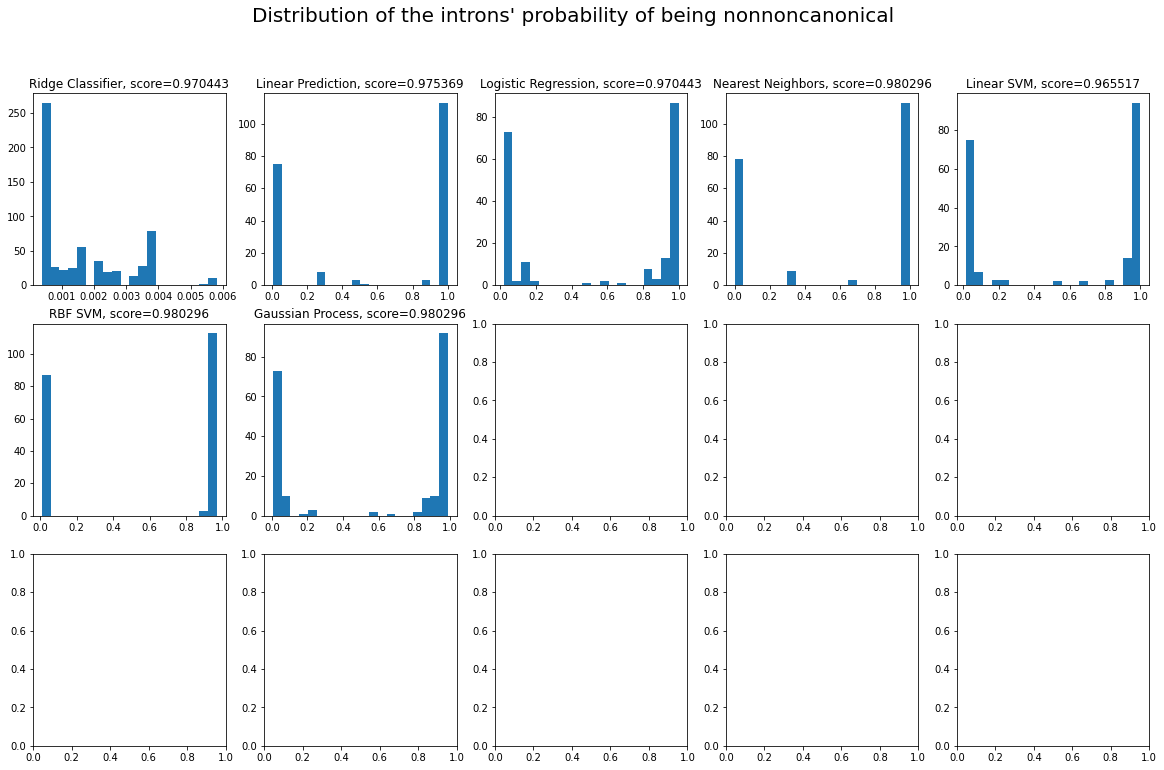

In [8]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.datasets import make_moons, make_circles, make_classification
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.linear_model import RidgeClassifier
from sklearn.linear_model import LogisticRegression


X_train, X_test, y_train, y_test = train_test_split(introns_set[columns[:-1]], introns_set[columns[-1]], random_state=123)
#X_train, X_test, y_train, y_test = train_test_split(introns_variants, true_classes, random_state=123)

fig, ax = plt.subplots(3,5, figsize=(20,12))
fig.suptitle("Distribution of the introns' probability of being nonnoncanonical", fontsize=20)
f=open("wrong_introns_wo-intermediate.fasta", 'w')

names = [
    "Ridge Classifier",
    "Linear Prediction",
    "Logistic Regression",
    "Nearest Neighbors",
    "Linear SVM",
    "RBF SVM",
    "Gaussian Process",
    "Decision Tree",
    "Random Forest",
    "Neural Net",
    "AdaBoost",
    "Naive Bayes",
    "QDA",
]

classifiers = [
    RidgeClassifier(),
    SGDClassifier(loss='log'),
    LogisticRegression(random_state=0),
    KNeighborsClassifier(3),
    SVC(kernel="linear", C=0.025, probability=True),
    SVC(gamma=2, C=1, probability=True),
    GaussianProcessClassifier(1.0 * RBF(1.0)),
    DecisionTreeClassifier(max_depth=5),
    RandomForestClassifier(max_depth=5, n_estimators=10, max_features=1),
    MLPClassifier(alpha=1, max_iter=1000),
    AdaBoostClassifier(),
    GaussianNB(),
    QuadraticDiscriminantAnalysis(),
]

wagi_cech = []
zle_zaklasyfikowane_introny={}

for idx, clfs in list(enumerate(list(zip(names, classifiers))))[:7]:
    i_ax = ax.reshape(1,-1)[0,idx]
    clf_name, clf = clfs
    #print("\n", clf_name)
    clf.fit(X_train, y_train)
    score = clf.score(X_test, y_test)
    if hasattr(clf, "coef_"):
        print(clf_name, "has coef")
        wagi_cech.append((clf_name, clf.coef_))
    if hasattr(clf, "predict_proba"):
        print(clf_name, "has proba")
        probs = clf.predict_proba(X_test)[:,1]
    elif hasattr(clf, "decision_function"):
        print(clf_name, "has decision function")
        d = clf.decision_function(X_train)
        probs = np.exp(d) / np.sum(np.exp(d))
    i_ax.hist(probs, bins=20)
    i_ax.set_title("%s, score=%f" %(clf_name, score))
    #print(score)
    
    prediction = clf.predict(X_test)
    wrong_introns = introns_obj.iloc[y_test.index[prediction != y_test].tolist()]
    wrong_labels = prediction[prediction != y_test]

    for wi, lb in zip(wrong_introns,wrong_labels):
        s = wi.prev_exon.sequence[-10:] + wi.sequence + wi.next_exon.sequence[:10]
        knk = "NK" if lb == 1 else "K/I"
        f.write(">%s||%s manual: %s predicted: %s\n%s\n" %(clf_name, wi.__str__(), wi.man_annotation, knk, s))
    
f.close()
#plt.savefig("przewidziane_pstwo_12.png", format='png', transparent=False)
#plt.show()

In [13]:
'''Cross-validation, wybór najlepszego klasyfikatora'''
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, f1_score, make_scorer

X, y = introns_set[columns[:-1]], introns_set[columns[-1]]

trained_classificators={}

for idx, clfs in enumerate(list(zip(names, classifiers))):
    clf_name, clf = clfs
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    #score = cross_val_score(clf, X, y, scoring=, cv=10)
    #print(clf_name, sum(score)/len(score), "accuracy: %f, f-score: %f" %())
    print(clf_name,"accuracy: %f, f-score: %f" %(accuracy_score(y_test, y_pred), f1_score(y_test, y_pred)))
    trained_classificators[clf_name] = clf

Ridge Classifier accuracy: 0.970443, f-score: 0.974138
Linear Prediction accuracy: 0.980296, f-score: 0.982906
Logistic Regression accuracy: 0.970443, f-score: 0.974138
Nearest Neighbors accuracy: 0.980296, f-score: 0.982906
Linear SVM accuracy: 0.965517, f-score: 0.969697
RBF SVM accuracy: 0.980296, f-score: 0.982906
Gaussian Process accuracy: 0.980296, f-score: 0.982906
Decision Tree accuracy: 0.975369, f-score: 0.978541
Random Forest accuracy: 0.965517, f-score: 0.970464
Neural Net accuracy: 0.965517, f-score: 0.969697
AdaBoost accuracy: 0.970443, f-score: 0.974138
Naive Bayes accuracy: 0.975369, f-score: 0.978541
QDA accuracy: 0.921182, f-score: 0.928571


/home/semik/miniconda3/lib/python3.8/site-packages/sklearn/discriminant_analysis.py:878: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


In [ ]:
'''test klasyfikatorów na wszystkich intronach z wariantami'''
clf = trained_classificators["RBF SVM"]
#clf = trained_classificators.get("Gaussian process")
predictions=[]
introns_df = pd.DataFrame({"introns_obj": introns_obj, "klasa": introns_set['klasa']})
for i in list(introns_df.iterrows()):
    intron, klasa = i[1]['introns_obj'], i[1]['klasa']
    variants = [intron]+intron.variations
    v_c = pd.DataFrame([compute_characteristics(var) for var in variants], 
                       columns=['eY| i', 'e |Ri', 'C-G', 'A-T', 'G-C', 'CAG - CGT', 'iY| e', 'i |Re'])
    pred_prob = np.array(clf.predict_proba(v_c))
    pred_class = np.array(clf.predict(v_c))
    #predictions.append((pred1, klasa))
    predictions.append((pred_prob, klasa))
    #print(pred_prob, pred_class, klasa)

In [ ]:
s = sum([np.argmax(p[:,1])==0 if k==1 else np.argmax(p[:,0])==0 for p, k in predictions])
len(predictions), s


In [ ]:
wagi_cech_n=[(n, w/np.linalg.norm(w)) for n, w in wagi_cech]
fig, ax = plt.subplots()
for n, i in wagi_cech_n:
    plt.plot(i[0], label=n)

ticks_loc = ax.get_xticks().tolist()
ax.set_xticks(range(len(columns)))
ax.set_xticklabels(columns)
ax.set_title("Characteristics' weights")

summed = sum([i for n,i in wagi_cech_n]).flatten()
summed = summed/(len(wagi_cech_n))#np.linalg.norm(summed)
for i in range(len(summed)):
    print(columns[i],"\t", summed[i])
plt.plot(range(len(summed)),summed , "k*", label="mean")
plt.legend()
plt.savefig("wagi_cech.png")
plt.show()

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(10,5))
fig.suptitle("Distribution of expressed characteristics in correclty classified introns", fontsize=20)

introns_set['suma'] = introns_set[columns[:-1]].sum(axis=1)
ax[0].hist(introns_set['suma'][introns_set['klasa']==1])
ax[0].set_title("Noncanonical introns")
ax[1].hist(introns_set['suma'][introns_set['klasa']==0])
ax[1].set_title("Not-noncanonical introns")

plt.savefig("spelnione_cechy.png", transparent=False)

### zamach za pomoca pawla

In [ ]:
for name, gene in genes.items():
    if name == 'EL|STRG.5113.1|scaffold_3161:4719-42082':
        print(name)
        for intron in gene.introns:
            if intron.scaffold_start == 36255:
                print(intron)
                print(intron.man_annotation)
                print(intron.sequence)